In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import image as img

#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


## Applicazione della SVD alla compressione di una matrice

Sia $A\in{\mathbb R}^{m\times n}$ una matrice di rango $k$ e siano $U,\Sigma, V$ le matrici della sua decomposizione SVD
$$A = U\Sigma V^T$$
Se indichiamo con $u_1,...,u_m$ le colonne di $U$, con $v_1,...,v_n$ le colonne di $V$e con $\sigma_1\geq\sigma_2\geq...\geq\sigma_k>0$ i valori singolari, la decomposizione $SVD$ si esprime anche come
$$A = \sigma_1u_1v_1^T+\sigma_2u_2v_2^T+...+\sigma_ku_kv_k^T $$
Fissato un intero $\bar k\leq k$, si può definire una approssimazione $\bar A$ di $A$ nel modo seguente
$$\bar A =\sigma_1u_1v_1^T+\sigma_2u_2v_2^T+...+\sigma_{\bar k}u_{\bar k}{v_{\bar k}}^T  $$

Per le proprietà delle matrici ortogonali si ha che
$$\begin{array}{lcl} \|A-\bar A\|_2 &=& \sigma_{\bar k +1}\\
\|A-\bar A\|_F &=& \sqrt{{\sigma_{\bar k +1}}^2+...+\sigma_k^2 }\end{array}$$

Questa formula può essere interpretata come un'algoritmo di compressione (con perdita) di una matrice, che, invece di essere rappresentata mediante i suoi elementi ($nm$ locazioni floating point), richiede la memorizzazione dei vettori $u_1,...,u_{\bar k}$, $v_1,...,v_{\bar k}$ e degli scalari $\sigma_1,...,\sigma_{\bar k}$ ($\bar k(m+n+1) $ locazioni floating point).

La perdita di informazione può essere regolata tenendo conto del fatto che in molte situazioni una matrice ha pochi valori singolari significativamente più grandi rispetto a tutti gli altri.

1. Scriviamo il codice che calcola la matrice approssimata a partire dalla decomposizione SVD
2. Applichiamo la compressione ad una matrice che è costituita dai pixel di un'immagine digitale.



In [ ]:
def compr_svd(U,S,V,k):
    m = U.shape[0]
    n = V.shape[1]
    A = np.zeros((m,n),dtype=float)
    for i in range(k):
        A = A + S[i]*np.outer(U[:,i],V[:,i])
    return A


#carichiamo un'immagine (è RGB)
#image = img.imread('/content/drive/MyDrive/Calcolo Numerico 2025-Informatica/Colab_lezione_pronti/Dati/durer.jpg')
image = "durer.jpg"
plt.imshow(image)

(n,m,p) = image.shape
print('Image size:',n,m,p,'\nData type:',image.dtype)
#Trasformiamo l'immagine da uint8 a float64
image = image.astype(np.float64)

#Trasformiamo l'immagine a colori in scala di grigi: questa operazione si
#effettua con una somma pesata dei tre canali RGB i cui coefficienti sono
#    0.299, 0.587, 0.114

A = 0.299*image[:,:,0]+0.587*image[:,:,1]+0.114*image[:,:,2]

#Ritagliamo una porzione dell'immagine
A = A[115:240,510:640]
fig = plt.figure()
ax = fig.add_subplot(1,2,1)
ax.imshow(A,cmap='gray')

(n,m) = A.shape
print('detail size:',n,m)
(U,S,Vt) = np.linalg.svd(A)

plt.figure()
plt.plot(S)

k = 20
A_compr = compr_svd(U,S,Vt.T,k)
ax = fig.add_subplot(1,2,2)
ax.imshow(A_compr,cmap='gray')
plt.show()

In [ ]:
def compr_svd(U,S,V,k):
    m = U.shape[0]
    n = V.shape[1]
    A = np.zeros((m,n),dtype=float)
    for i in range(k):
        A = A + S[i]*np.outer(U[:,i],V[:,i])
    return A

Image size: 899 677 3 
Data type: uint8


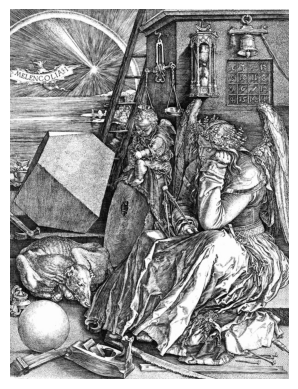

In [ ]:
#carichiamo un'immagine (è RGB)
#image = img.imread('/content/drive/MyDrive/Calcolo Numerico 2025-Informatica/Colab_lezione_pronti/Dati/durer.jpg')
image = "durer.jpg"
plt.imshow(image)
plt.axis('off')

(n,m,p) = image.shape
print('Image size:',n,m,p,'\nData type:',image.dtype)
#Trasformiamo l'immagine da uint8 a float64
image = image.astype(np.float64)

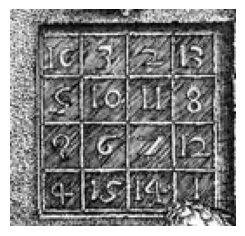

In [ ]:
#Trasformiamo l'immagine da RGB a scala di grigi: questa operazione si
#effettua con una somma pesata dei tre canali RGB i cui coefficienti sono
#    0.299, 0.587, 0.114

A = 0.299*image[:,:,0]+0.587*image[:,:,1]+0.114*image[:,:,2]

#Ritagliamo una porzione dell'immagine
A = A[115:240,510:640]
fig = plt.figure()
ax = fig.add_subplot(1,2,1)
ax.imshow(A,cmap='gray')
plt.axis('off')
plt.show()

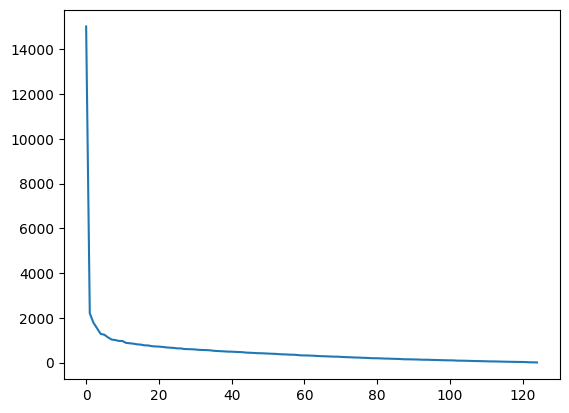

In [ ]:
#Calcoliamo la SVD della matrice e plottiamo i valori singolari
(U,S,Vt) = np.linalg.svd(A)

plt.figure()
plt.plot(S)
plt.show()
#Osserviamo che ci sono pochi valori singolari (1-2 ordini di grandezza) molto grandi rispetto agli altri

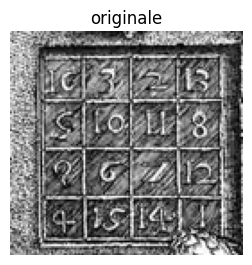

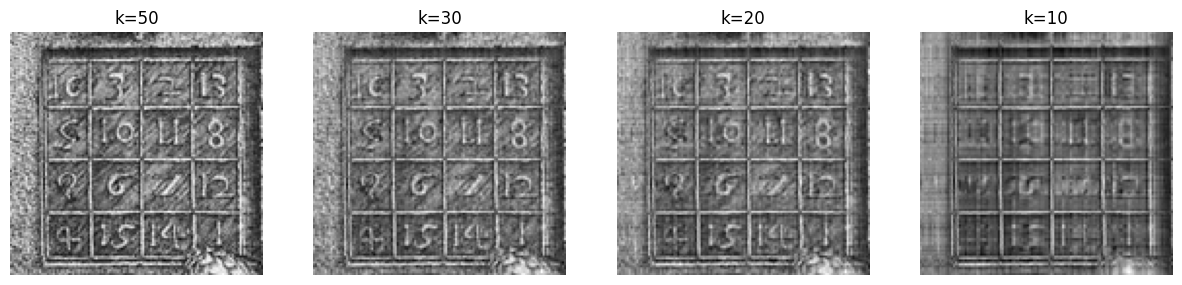

In [ ]:
#Calcoliamo la compressione dell'immagine/matrice per diversi valori di k
kvec = np.array([50,30,20,10])
nk   = len(kvec)
err2 = np.zeros(nk) #per contenere gli errori in norma2
errF = np.zeros(nk) #per contenere gli errori in norma di Frobenius

fig = plt.figure(111,figsize=(3,3))
plt.imshow(A,cmap='gray')
plt.axis('off')
plt.title('originale')
fig, axs = plt.subplots(1,nk, figsize=(15, 5))
for i in range(nk):
  barA = compr_svd(U,S,Vt.T,kvec[i])
  err2[i] = np.linalg.norm(A-barA,2)
  errF[i] = np.linalg.norm(A-barA) #Frobenius è il default
  axs[i].imshow(barA,cmap='gray')
  axs[i].axis('off')
  axs[i].set_title(f"k={kvec[i]}")



In [ ]:
#valutiamo numericamente l'errore e verifichiamo la correttezza delle formule
#dell'errore basate sui valori singolari
for i in range(nk):
  bark = kvec[i]
  sum_sigma = np.sqrt((S[bark:]**2).sum())
  print(f"k={bark}, err2 = {err2[i]:.4f}, errF = {errF[i]:.4f} | sigma_k+1 = {S[bark]:.4f}, sum_sigma = {sum_sigma:.4f} ")

k=50, err2 = 402.9250, errF = 1801.9546 | sigma_k+1 = 402.9250, sum_sigma = 1801.9546 
k=30, err2 = 586.1464, errF = 2856.5004 | sigma_k+1 = 586.1464, sum_sigma = 2856.5004 
k=20, err2 = 715.7196, errF = 3520.1386 | sigma_k+1 = 715.7196, sum_sigma = 3520.1386 
k=10, err2 = 963.6172, errF = 4371.7635 | sigma_k+1 = 963.6172, sum_sigma = 4371.7635 
